In [1]:
import numpy as np
import matplotlib.pyplot as plt
# import image pillow
from PIL import Image

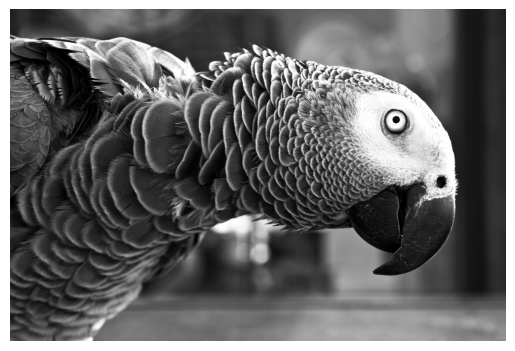

Image size:  (1920, 1285)


In [2]:
# read parrot.png
parrot = Image.open('parrot.png')
plt.imshow(parrot)
plt.axis('off')
plt.show()

print('Image size: ', parrot.size)

In [3]:
# convert to numpy
I = np.array(parrot).astype(float)  # avoid uint8 overflow in later arithmetic
# let us compute the dimension of the vector space:
print('Shape of image:')
print(I.shape)
print('Number of pixels (dimension of space): ')
dim = I.shape[0] * I.shape[1] 
print(dim)

Shape of image:
(1285, 1920)
Number of pixels (dimension of space): 
2467200


In [4]:
# define a convolution kernel, to compute the 
# average of a square portion of the image
m = 40
A = np.ones((m, m)) / (m * m)
print(A)   

[[0.000625 0.000625 0.000625 ... 0.000625 0.000625 0.000625]
 [0.000625 0.000625 0.000625 ... 0.000625 0.000625 0.000625]
 [0.000625 0.000625 0.000625 ... 0.000625 0.000625 0.000625]
 ...
 [0.000625 0.000625 0.000625 ... 0.000625 0.000625 0.000625]
 [0.000625 0.000625 0.000625 ... 0.000625 0.000625 0.000625]
 [0.000625 0.000625 0.000625 ... 0.000625 0.000625 0.000625]]


In [5]:
I_blur = np.zeros((I.shape[0]-m, I.shape[1]-m))

for i in range(I.shape[0]-m):
    for j in range(I.shape[1]-m):
        
        I_blur[i, j] = np.sum(A * I[i:i+m, j:j+m]) / (m * m)
        
        

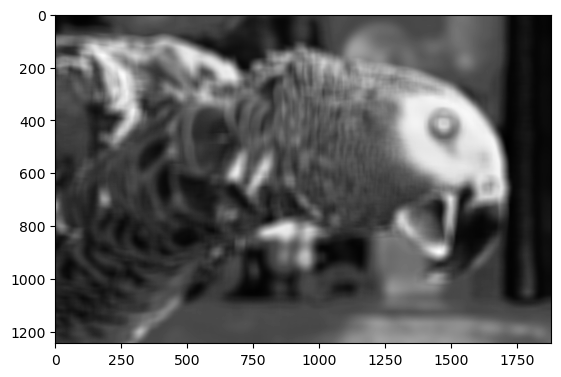

In [6]:
plt.figure()
plt.imshow(I_blur, cmap='gray')
plt.show()

In [7]:
# We wrap the blurring into a function

def blur(I, m=40):
    "Blur the image I with an m x m kernel"
    A = np.ones((m, m)) / (m * m)
    I2 = np.zeros((I.shape[0]-m, I.shape[1]-m))
    for i in range(I.shape[0]-m):
        for j in range(I.shape[1]-m):
            I2[i, j] = np.sum(A * I[i:i+m, j:j+m])
    return I2


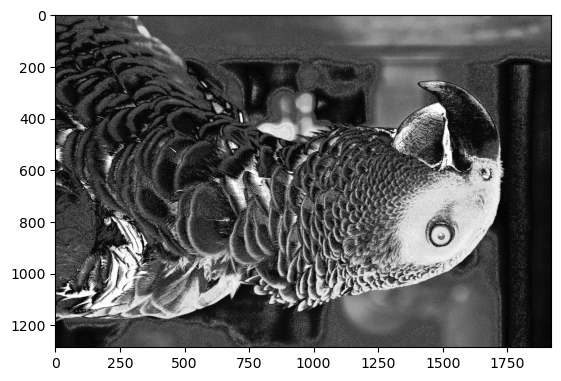

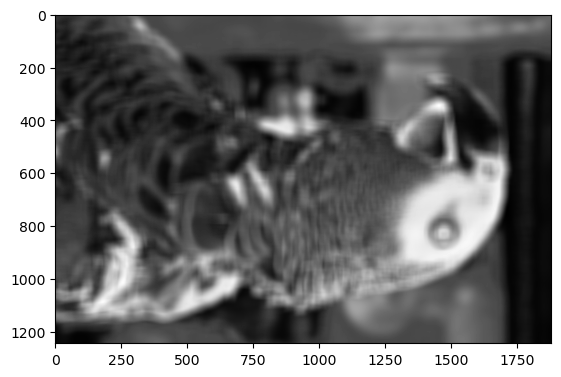

In [8]:
# Make a flipped image
FI = np.flipud(I)

# Blur it
BFI = blur(FI)

plt.figure()
plt.imshow(FI, cmap='gray')
plt.show()

plt.figure()
plt.imshow(BFI, cmap='gray')
plt.show()


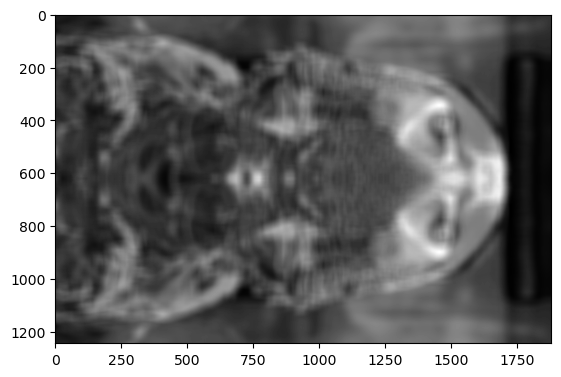

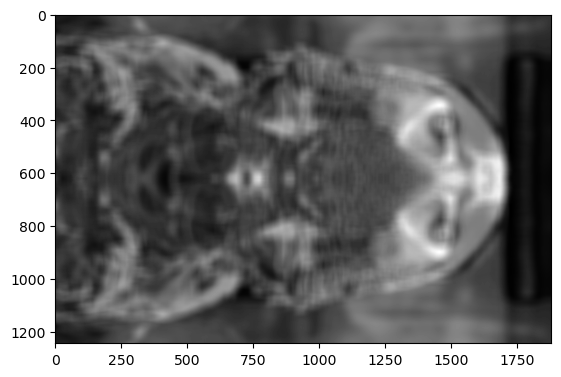

In [10]:
# Let us take linear combination _then_ blur:
# and blur _then_ linear combination

BI = blur(I)
X = 0.5 * (BI + BFI)
Y = blur(0.5 * (I + FI))


plt.figure()
plt.imshow(X, cmap = 'gray')
plt.show()

plt.figure()
plt.imshow(Y, cmap = 'gray')
plt.show()

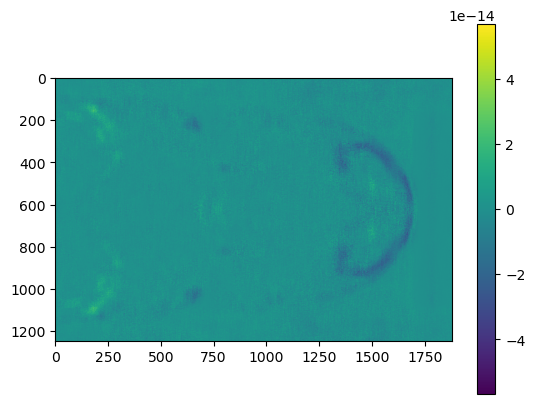

In [11]:
# compare with linear combination of blurred images
plt.figure()

plt.imshow(X - Y)
plt.colorbar()